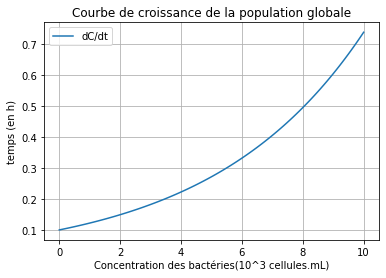

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres de la simulation
rmax = 0.2  # taux de croissance maximal (h⁻¹)
C0 = 0.1  # Concentration des cellules bactériennes au début de la simulation (10^3 cellules.mL-1)
T = 10 # durée totale de la simulation (heures)
dt = 0.1 # pas de temps (heures)
N_steps = int(T / dt)

# Simulation
time = np.linspace(0, T, N_steps)
C = C0 * np.exp(rmax * time)

# Tracé du graphique
plt.title('Courbe de croissance de la population globale')  # Titre du graphique
plt.plot(time, C, label='dC/dt') # Nom de la courbe
plt.xlabel('Concentration des bactéries(10^3 cellules.mL)') # Axe des X
plt.ylabel('temps (en h)') # Axe des Y
plt.grid(True)
plt.legend()
plt.show()

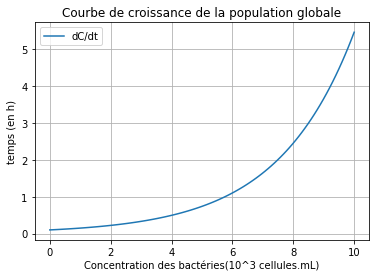

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres de la simulation
rmax = 0.4  # taux de croissance maximal (h⁻¹)
C0 = 0.1  # Concentration des cellules bactériennes au début de la simulation (10^3 cellules.mL-1)
T = 10 # durée totale de la simulation (heures)
dt = 0.1 # pas de temps (heures)
N_steps = int(T / dt)

# Simulation
time = np.linspace(0, T, N_steps)
C = C0 * np.exp(rmax * time)

# Tracé du graphique
plt.title('Courbe de croissance de la population globale')  # Titre du graphique
plt.plot(time, C, label='dC/dt') # Nom de la courbe
plt.xlabel('Concentration des bactéries(10^3 cellules.mL)') # Axe des X
plt.ylabel('temps (en h)') # Axe des Y
plt.grid(True)
plt.legend()
plt.show()

Nous avons un temps de doublement de la population légerement supérieur au début, mais le rMax plus élevé rend la courbe plsu exponentielle donc bien plus rapide sur le long terme

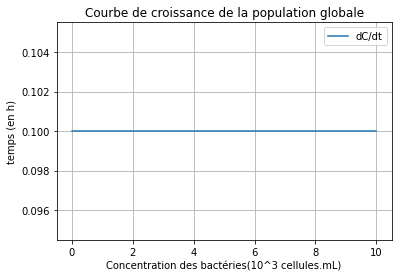

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres de la simulation
rmax = 0  # taux de croissance maximal (h⁻¹)
C0 = 0.1  # Concentration des cellules bactériennes au début de la simulation (10^3 cellules.mL-1)
T = 10 # durée totale de la simulation (heures)
dt = 0.1 # pas de temps (heures)
N_steps = int(T / dt)

# Simulation
time = np.linspace(0, T, N_steps)
C = C0 * np.exp(rmax * time)

# Tracé du graphique
plt.title('Courbe de croissance de la population globale')  # Titre du graphique
plt.plot(time, C, label='dC/dt') # Nom de la courbe
plt.xlabel('Concentration des bactéries(10^3 cellules.mL)') # Axe des X
plt.ylabel('temps (en h)') # Axe des Y
plt.grid(True)
plt.legend()
plt.show()

Nous obtenons une croissance nulle, pas de doublement du nombre de populations

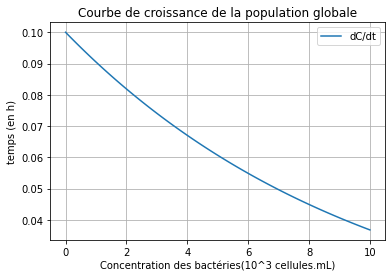

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres de la simulation
rmax = -0.1  # taux de croissance maximal (h⁻¹)
C0 = 0.1  # Concentration des cellules bactériennes au début de la simulation (10^3 cellules.mL-1)
T = 10 # durée totale de la simulation (heures)
dt = 0.1 # pas de temps (heures)
N_steps = int(T / dt)

# Simulation
time = np.linspace(0, T, N_steps)
C = C0 * np.exp(rmax * time)

# Tracé du graphique
plt.title('Courbe de croissance de la population globale')  # Titre du graphique
plt.plot(time, C, label='dC/dt') # Nom de la courbe
plt.xlabel('Concentration des bactéries(10^3 cellules.mL)') # Axe des X
plt.ylabel('temps (en h)') # Axe des Y
plt.grid(True)
plt.legend()
plt.show()

1. Nous avons une courbe exponentielle . Nous avons C0 = 0,1*10-3 c.mL-1 à t = 0, donc la population double quand C = 0,2 au bout de environ 0,11h 
On observe que plus rMax est élevé plus la courbe est exponentielle soit une croissance plus rapide; rMax = 0 donne donc une droite sans progression et un rMax négatif donne une courbe décroissante.
Ce modèle implique  des ressources et un espace infini dans un environnement parfait, là où normalement les ressources disponibles dans un milieu de culture sont limitantes,la population atteint un maxima et stagne en s'habituant et s'adaptant au milieu avant de parfois décroitre lorsqu'il n'y a pas de renouvellement de génération. On pourrait améliorer ce modèle en ajoutant une limite de croissance et intégrer une equation, un bruit stochastique pour jouer sur les évnements aléatoires auquels les bactéries peuvent faire face. Mais un autre problème est celui de pouvoir y intégrer un taux de croissance, négatif ce qui en général n'est pas possible en laboratoire. Cela dit cela ne prend pâs en compte les morts des cellules.


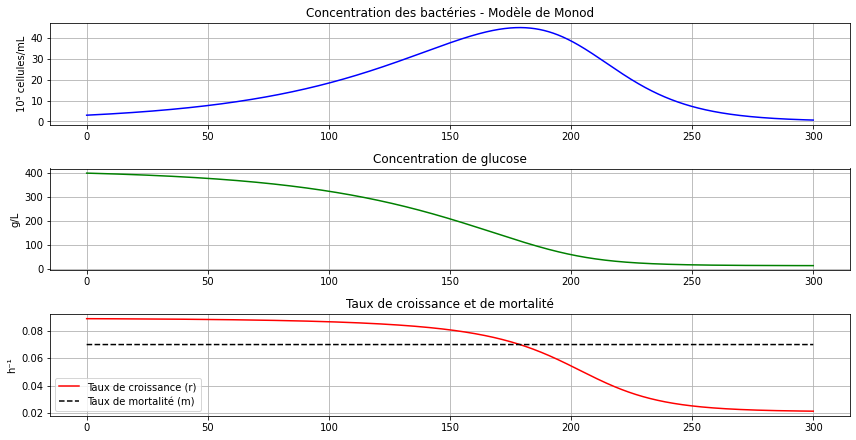

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# PARAMÈTRES DE LA SIMULATION
# ======================
T = 300          # Durée totale (heures)
dt = 0.1          # Pas de temps (heures)
N_steps = int(T / dt)  # Nombre de pas de temps

# ======================
# PARAMÈTRES DE LA SOUCHE
# ======================
rmax = 0.10       # Taux de croissance maximal (h⁻¹)
K = 50           # Affinité pour le substrat (g/L)
m0 = 0.07         # Taux de mortalité minimal (h⁻¹)
C0 = 3 # Concentration initiale de bactéries (10³ cellules/mL)

# ======================
# PARAMÈTRES DU SUBSTRAT (GLUCOSE)
# ======================
initial_glucose = 400  # Concentration initiale de glucose (g/L)
glucose_inflow = 0      # Flux entrant de glucose (g/L/h)

# ======================
# INITIALISATION DES TABLEAUX
# ======================
C = np.zeros(N_steps)          # Concentration bactérienne
glucose_level = np.zeros(N_steps)
growth_rate = np.zeros(N_steps)
mortality_rate = np.zeros(N_steps)

# ======================
# CONDITIONS INITIALES
# ======================
C[0] = C0
glucose_level[0] = initial_glucose
growth_rate[0] = rmax * glucose_level[0] / (K + glucose_level[0])
mortality_rate[0] = m0

# ======================
# SIMULATION
# ======================
for i in range(1, N_steps):
    # Calcul des taux
    r = rmax * glucose_level[i-1] / (K + glucose_level[i-1])

    # Mise à jour de la population bactérienne
    C[i] = C[i-1] + dt * (r - m0) * C[i-1]

    # Mise à jour du glucose (consommation + flux entrant)
    glucose_level[i] = glucose_level[i-1] - dt * r * C[i-1] + glucose_inflow * dt

    # Stockage des taux
    growth_rate[i] = r
    mortality_rate[i] = m0

# ======================
# AXE DES X EN HEURES
# ======================
time = np.linspace(0, T, N_steps)

# ======================
# TRACÉ DES COURBES
# ======================
plt.figure(figsize=(12, 8))

# 1. Concentration bactérienne
plt.subplot(4, 1, 1)
plt.plot(time, C, label='Nombre de bactéries', color='blue')
plt.title('Concentration des bactéries - Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.grid(True)

# 2. Concentration de glucose
plt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Concentration de glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)

# 3. Taux de croissance ET mortalité (sur le même graphique)
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate, label='Taux de croissance (r)', color='red')
plt.plot(time, mortality_rate, label='Taux de mortalité (m)', color='black', linestyle='--')  # Ligne noire en pointillé
plt.title('Taux de croissance et de mortalité')
plt.ylabel('h⁻¹')
plt.legend()  # Affiche la légende pour les deux courbes
plt.grid(True)

plt.tight_layout()
plt.show()

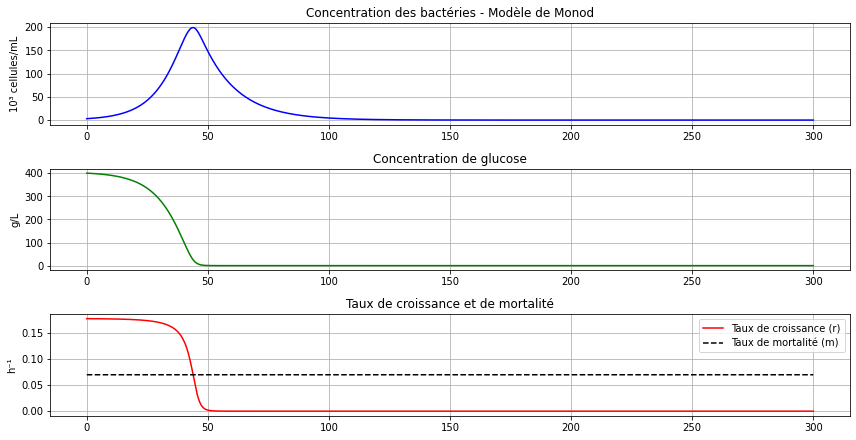

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# PARAMÈTRES DE LA SIMULATION
# ======================
T = 300          # Durée totale (heures)
dt = 0.1          # Pas de temps (heures)
N_steps = int(T / dt)  # Nombre de pas de temps

# ======================
# PARAMÈTRES DE LA SOUCHE
# ======================
rmax = 0.20       # Taux de croissance maximal (h⁻¹)
K = 50           # Affinité pour le substrat (g/L)
m0 = 0.07         # Taux de mortalité minimal (h⁻¹)
C0 = 3 # Concentration initiale de bactéries (10³ cellules/mL)

# ======================
# PARAMÈTRES DU SUBSTRAT (GLUCOSE)
# ======================
initial_glucose = 400  # Concentration initiale de glucose (g/L)
glucose_inflow = 0      # Flux entrant de glucose (g/L/h)

# ======================
# INITIALISATION DES TABLEAUX
# ======================
C = np.zeros(N_steps)          # Concentration bactérienne
glucose_level = np.zeros(N_steps)
growth_rate = np.zeros(N_steps)
mortality_rate = np.zeros(N_steps)

# ======================
# CONDITIONS INITIALES
# ======================
C[0] = C0
glucose_level[0] = initial_glucose
growth_rate[0] = rmax * glucose_level[0] / (K + glucose_level[0])
mortality_rate[0] = m0

# ======================
# SIMULATION
# ======================
for i in range(1, N_steps):
    # Calcul des taux
    r = rmax * glucose_level[i-1] / (K + glucose_level[i-1])

    # Mise à jour de la population bactérienne
    C[i] = C[i-1] + dt * (r - m0) * C[i-1]

    # Mise à jour du glucose (consommation + flux entrant)
    glucose_level[i] = glucose_level[i-1] - dt * r * C[i-1] + glucose_inflow * dt

    # Stockage des taux
    growth_rate[i] = r
    mortality_rate[i] = m0

# ======================
# AXE DES X EN HEURES
# ======================
time = np.linspace(0, T, N_steps)

# ======================
# TRACÉ DES COURBES
# ======================
plt.figure(figsize=(12, 8))

# 1. Concentration bactérienne
plt.subplot(4, 1, 1)
plt.plot(time, C, label='Nombre de bactéries', color='blue')
plt.title('Concentration des bactéries - Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.grid(True)

# 2. Concentration de glucose
plt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Concentration de glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)

# 3. Taux de croissance ET mortalité (sur le même graphique)
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate, label='Taux de croissance (r)', color='red')
plt.plot(time, mortality_rate, label='Taux de mortalité (m)', color='black', linestyle='--')  # Ligne noire en pointillé
plt.title('Taux de croissance et de mortalité')
plt.ylabel('h⁻¹')
plt.legend()  # Affiche la légende pour les deux courbes
plt.grid(True)

plt.tight_layout()
plt.show()

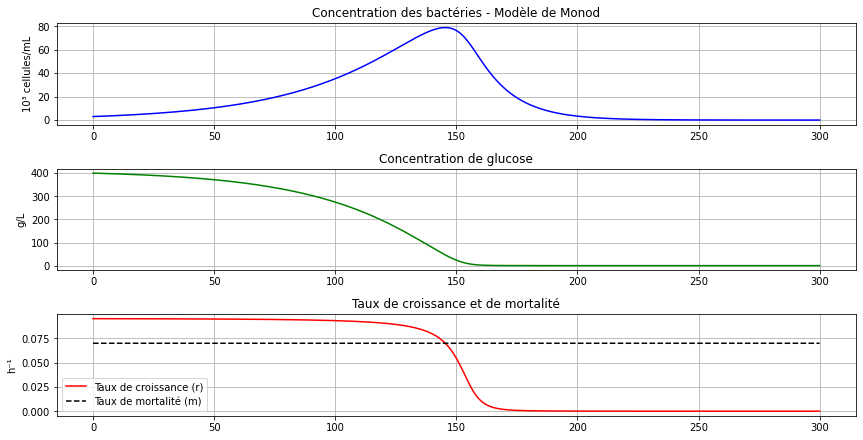

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# PARAMÈTRES DE LA SIMULATION
# ======================
T = 300          # Durée totale (heures)
dt = 0.1          # Pas de temps (heures)
N_steps = int(T / dt)  # Nombre de pas de temps

# ======================
# PARAMÈTRES DE LA SOUCHE
# ======================
rmax = 0.10       # Taux de croissance maximal (h⁻¹)
K = 20           # Affinité pour le substrat (g/L)
m0 = 0.07         # Taux de mortalité minimal (h⁻¹)
C0 = 3 # Concentration initiale de bactéries (10³ cellules/mL)

# ======================
# PARAMÈTRES DU SUBSTRAT (GLUCOSE)
# ======================
initial_glucose = 400  # Concentration initiale de glucose (g/L)
glucose_inflow = 0      # Flux entrant de glucose (g/L/h)

# ======================
# INITIALISATION DES TABLEAUX
# ======================
C = np.zeros(N_steps)          # Concentration bactérienne
glucose_level = np.zeros(N_steps)
growth_rate = np.zeros(N_steps)
mortality_rate = np.zeros(N_steps)

# ======================
# CONDITIONS INITIALES
# ======================
C[0] = C0
glucose_level[0] = initial_glucose
growth_rate[0] = rmax * glucose_level[0] / (K + glucose_level[0])
mortality_rate[0] = m0

# ======================
# SIMULATION
# ======================
for i in range(1, N_steps):
    # Calcul des taux
    r = rmax * glucose_level[i-1] / (K + glucose_level[i-1])

    # Mise à jour de la population bactérienne
    C[i] = C[i-1] + dt * (r - m0) * C[i-1]

    # Mise à jour du glucose (consommation + flux entrant)
    glucose_level[i] = glucose_level[i-1] - dt * r * C[i-1] + glucose_inflow * dt

    # Stockage des taux
    growth_rate[i] = r
    mortality_rate[i] = m0

# ======================
# AXE DES X EN HEURES
# ======================
time = np.linspace(0, T, N_steps)

# ======================
# TRACÉ DES COURBES
# ======================
plt.figure(figsize=(12, 8))

# 1. Concentration bactérienne
plt.subplot(4, 1, 1)
plt.plot(time, C, label='Nombre de bactéries', color='blue')
plt.title('Concentration des bactéries - Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.grid(True)

# 2. Concentration de glucose
plt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Concentration de glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)

# 3. Taux de croissance ET mortalité (sur le même graphique)
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate, label='Taux de croissance (r)', color='red')
plt.plot(time, mortality_rate, label='Taux de mortalité (m)', color='black', linestyle='--')  # Ligne noire en pointillé
plt.title('Taux de croissance et de mortalité')
plt.ylabel('h⁻¹')
plt.legend()  # Affiche la légende pour les deux courbes
plt.grid(True)

plt.tight_layout()
plt.show()

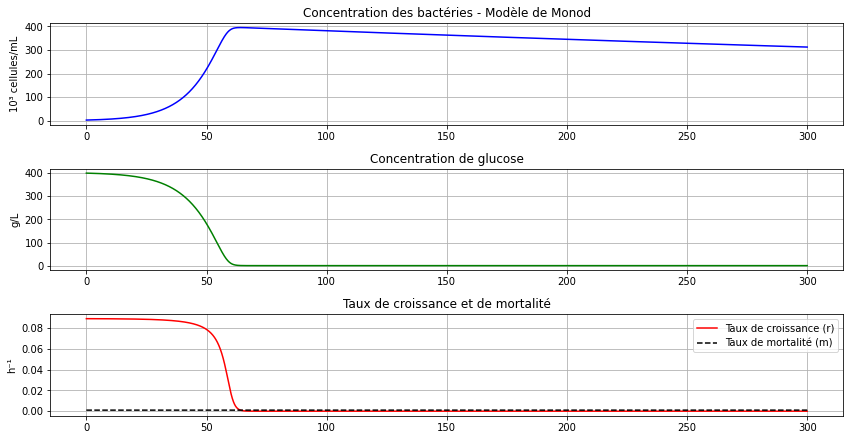

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# PARAMÈTRES DE LA SIMULATION
# ======================
T = 300          # Durée totale (heures)
dt = 0.1          # Pas de temps (heures)
N_steps = int(T / dt)  # Nombre de pas de temps

# ======================
# PARAMÈTRES DE LA SOUCHE
# ======================
rmax = 0.10       # Taux de croissance maximal (h⁻¹)
K = 50           # Affinité pour le substrat (g/L)
m0 = 0.001         # Taux de mortalité minimal (h⁻¹)
C0 = 3 # Concentration initiale de bactéries (10³ cellules/mL)

# ======================
# PARAMÈTRES DU SUBSTRAT (GLUCOSE)
# ======================
initial_glucose = 400  # Concentration initiale de glucose (g/L)
glucose_inflow = 0      # Flux entrant de glucose (g/L/h)

# ======================
# INITIALISATION DES TABLEAUX
# ======================
C = np.zeros(N_steps)          # Concentration bactérienne
glucose_level = np.zeros(N_steps)
growth_rate = np.zeros(N_steps)
mortality_rate = np.zeros(N_steps)

# ======================
# CONDITIONS INITIALES
# ======================
C[0] = C0
glucose_level[0] = initial_glucose
growth_rate[0] = rmax * glucose_level[0] / (K + glucose_level[0])
mortality_rate[0] = m0

# ======================
# SIMULATION
# ======================
for i in range(1, N_steps):
    # Calcul des taux
    r = rmax * glucose_level[i-1] / (K + glucose_level[i-1])

    # Mise à jour de la population bactérienne
    C[i] = C[i-1] + dt * (r - m0) * C[i-1]

    # Mise à jour du glucose (consommation + flux entrant)
    glucose_level[i] = glucose_level[i-1] - dt * r * C[i-1] + glucose_inflow * dt

    # Stockage des taux
    growth_rate[i] = r
    mortality_rate[i] = m0

# ======================
# AXE DES X EN HEURES
# ======================
time = np.linspace(0, T, N_steps)

# ======================
# TRACÉ DES COURBES
# ======================
plt.figure(figsize=(12, 8))

# 1. Concentration bactérienne
plt.subplot(4, 1, 1)
plt.plot(time, C, label='Nombre de bactéries', color='blue')
plt.title('Concentration des bactéries - Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.grid(True)

# 2. Concentration de glucose
plt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Concentration de glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)

# 3. Taux de croissance ET mortalité (sur le même graphique)
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate, label='Taux de croissance (r)', color='red')
plt.plot(time, mortality_rate, label='Taux de mortalité (m)', color='black', linestyle='--')  # Ligne noire en pointillé
plt.title('Taux de croissance et de mortalité')
plt.ylabel('h⁻¹')
plt.legend()  # Affiche la légende pour les deux courbes
plt.grid(True)

plt.tight_layout()
plt.show()

La concentration des bactéries ne cesse de croitre jusqu'à'ce que la concentration de glucose atteigne un point, une concentration trop basse et insuffisante pour faire prospérer la colonie, à ce moment la, le taux de croissance devient égal au taux de mortalité, mais comme la concentration de nutriment continue de baisser, le taux de croissance devient inférieur à la mortalité et donc la population de bactérie s'écroule. Ici le facteur limitant est plus précisément la concentration de glucose.
r est à son maximum dès le début quand r = rmax = 0.10. 
Le point d'inflexion de la concentration de bactéries, quand les bactéries commencent à décroitre, sur la courbe de concentration du glucose est plus ou  moins égale à 50g/L.

Pour que cette population se maintienne dans le temps il faudrzit renouveler régulièrement la concentration de glucose et ne pas dépasser un sueil minimal ou alors que le taux de croissance soit plus grand ou mortalité plus bas. On pourrait songer à complémenter le milieu pour augmenter l'affinité de cellules et baisser K (sueil min).

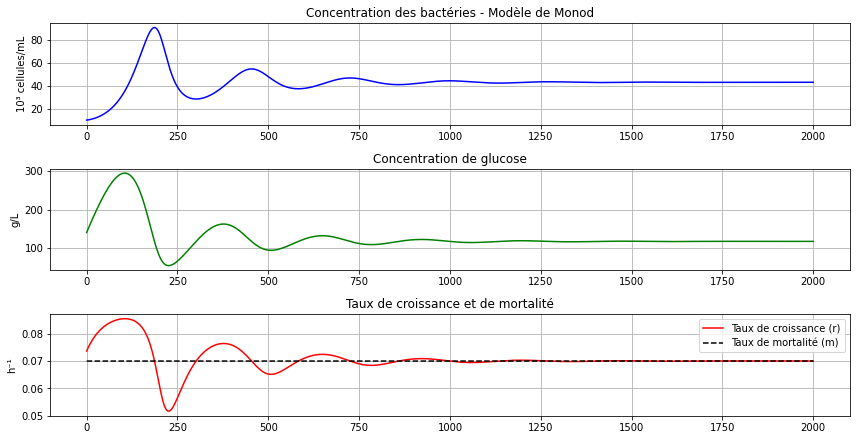

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# PARAMÈTRES DE LA SIMULATION
# ======================
T = 2000          # Durée totale (heures)
dt = 0.1          # Pas de temps (heures)
N_steps = int(T / dt)  # Nombre de pas de temps

# ======================
# PARAMÈTRES DE LA SOUCHE
# ======================
rmax = 0.10       # Taux de croissance maximal (h⁻¹)
K = 50           # Affinité pour le substrat (g/L)
m0 = 0.07         # Taux de mortalité minimal (h⁻¹)
C0 = 10 # Concentration initiale de bactéries (10³ cellules/mL)

# ======================
# PARAMÈTRES DU SUBSTRAT (GLUCOSE)
# ======================
initial_glucose = 140  # Concentration initiale de glucose (g/L)
glucose_inflow = 3     # Flux entrant de glucose (g/L/h)

# ======================
# INITIALISATION DES TABLEAUX
# ======================
C = np.zeros(N_steps)          # Concentration bactérienne
glucose_level = np.zeros(N_steps)
growth_rate = np.zeros(N_steps)
mortality_rate = np.zeros(N_steps)

# ======================
# CONDITIONS INITIALES
# ======================
C[0] = C0
glucose_level[0] = initial_glucose
growth_rate[0] = rmax * glucose_level[0] / (K + glucose_level[0])
mortality_rate[0] = m0

# ======================
# SIMULATION
# ======================
for i in range(1, N_steps):
    # Calcul des taux
    r = rmax * glucose_level[i-1] / (K + glucose_level[i-1])

    # Mise à jour de la population bactérienne
    C[i] = C[i-1] + dt * (r - m0) * C[i-1]

    # Mise à jour du glucose (consommation + flux entrant)
    glucose_level[i] = glucose_level[i-1] - dt * r * C[i-1] + glucose_inflow * dt

    # Stockage des taux
    growth_rate[i] = r
    mortality_rate[i] = m0

# ======================
# AXE DES X EN HEURES
# ======================
time = np.linspace(0, T, N_steps)

# ======================
# TRACÉ DES COURBES
# ======================
plt.figure(figsize=(12, 8))

# 1. Concentration bactérienne
plt.subplot(4, 1, 1)
plt.plot(time, C, label='Nombre de bactéries', color='blue')
plt.title('Concentration des bactéries - Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.grid(True)

# 2. Concentration de glucose
plt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Concentration de glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)

# 3. Taux de croissance ET mortalité (sur le même graphique)
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate, label='Taux de croissance (r)', color='red')
plt.plot(time, mortality_rate, label='Taux de mortalité (m)', color='black', linestyle='--')  # Ligne noire en pointillé
plt.title('Taux de croissance et de mortalité')
plt.ylabel('h⁻¹')
plt.legend()  # Affiche la légende pour les deux courbes
plt.grid(True)

plt.tight_layout()
plt.show()

La population présente des petites fluctuation au début pour la phase d'adaptation, le temps que la concentration de glucose soit stable qu'elle chute jusqu'à ce qu'elle ne dépende plus que du flux entrant de glucose. Elle oscille entre le fait qu'il y ait trop de bactérie par rapport à la concentration de glucose; ce qui provoaue une forte consommation de glucose avant de chuter fortement le temps que un flux de glucose soit suffisant renourrissant donc les cellules présentes et ainsi de suite jusqu'à ce qu'il y ait un équilibre avaec autant de cellules qu'il est possible de nourrir avec un influx de glucose de 23g/L/h.

Les courbes semblent toute se calquer sur un modèle d'oscillations sinusoidales non harmonique.

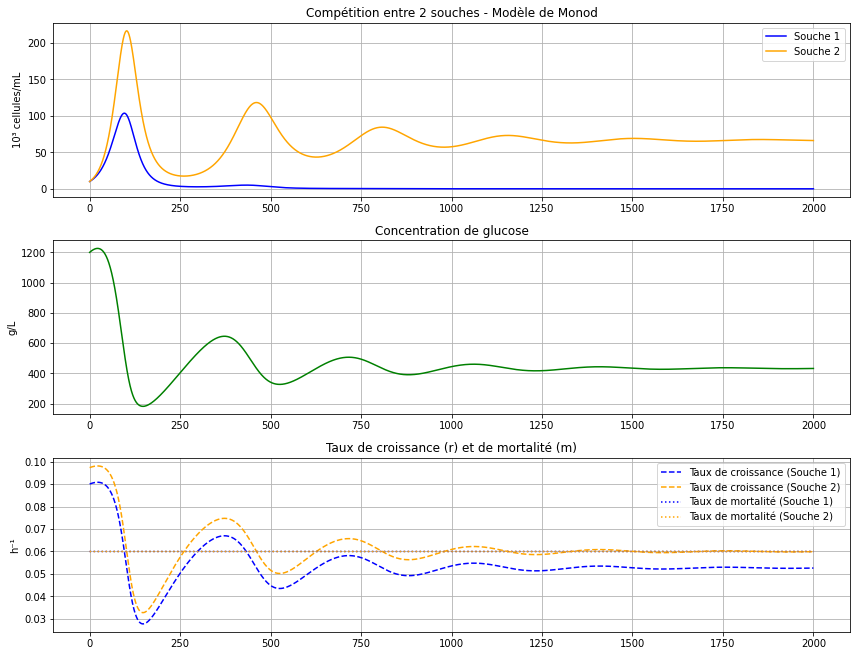

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# Paramètres pour la souche 1
# =============================================
rmax_1 = 0.15      # Taux de croissance maximal (souche 1)
m0_1 = 0.06      # Taux de mortalité de base (souche 1)
K_1 = 800        # Constante de demi-saturation (souche 1)

# =============================================
# Paramètres pour la souche 2
# =============================================
rmax_2 = 0.15      # Taux de croissance maximal (souche 2)
m0_2 = 0.06      # Taux de mortalité de base (souche 2)
K_2 = 650      # Constante de demi-saturation (souche 2) - affinité plus élevée pour le glucose

# =============================================
# Paramètres du glucose
# =============================================
initial_glucose = 1200   # Quantité initiale de glucose
glucose_inflow = 4      # Flux entrant de glucose (0 = système fermé)

# =============================================
# Conditions initiales
# =============================================
C0_1 = 10  # Concentration initiale de la souche 1
C0_2 = 10   # Concentration initiale de la souche 2

# =============================================
# Paramètres de la simulation
# =============================================
dt = 0.1         # Pas de temps
T = 2000         # Durée totale de la simulation
N_steps = int(T / dt)# Nombre de pas de temps

# =============================================
# Initialisation des tableaux
# =============================================
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)
mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)

# Conditions initiales
C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose
growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])
growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])
mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2

# =============================================
# Simulation
# =============================================
for i in range(1, N_steps):
    # Calcul des taux de croissance pour chaque souche (modèle de Monod)
    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    # Mortalité variable (augmente si le glucose est faible)
    #m_1 = m0_1 + 0.01 * (1 - glucose_level[i-1] / initial_glucose)
    #m_2 = m0_2 + 0.01 * (1 - glucose_level[i-1] / initial_glucose)

      # Mortalité constante
    m_1 = m0_1 
    m_2 = m0_2
    
    # Mise à jour des populations bactériennes
    C1[i] = C1[i-1] + dt * (r_1 - m_1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r_2 - m_2) * C2[i-1]

    # Consommation totale de glucose (somme des consommations des deux souches)
    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])
    glucose_level[i] = glucose_level[i-1] - dt * glucose_consumption + glucose_inflow * dt

    # Stockage des taux
    growth_rate_1[i] = r_1
    growth_rate_2[i] = r_2
    mortality_rate_1[i] = m_1
    mortality_rate_2[i] = m_2

# =============================================
# Temps pour l'axe des abscisses
# =============================================
time = np.linspace(0, T, N_steps)

# =============================================
# Tracé des courbes
# =============================================
plt.figure(figsize=(12, 12))

# Population des bactéries
plt.subplot(4, 1, 1)
plt.plot(time, C1, label='Souche 1', color='blue')
plt.plot(time, C2, label='Souche 2', color='orange')
plt.title('Compétition entre 2 souches - Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.legend()
plt.grid(True)

# Niveau de glucose
plt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)

# Taux de croissance et mortalité
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')
plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')
plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
plt.title('Taux de croissance (r) et de mortalité (m)')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)

# Taux de mortalité
#plt.subplot(4, 1, 4)
#plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
#plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
#plt.title('Taux de mortalité (m) au fil du temps')
#plt.xlabel('Temps')
#plt.ylabel('Taux de mortalité (m)')
#plt.legend()
#plt.grid(True)

plt.tight_layout()
plt.show()

Les courbes suivent les mêmes lignes que les graphiques précédents, soit des courbes oscillantes non harmonique; cependant le graphique de compétition entre les deux souches montre clairement que la souche 2 se démarque de la première qui s'effondre au niveau de la population là où la deuxième finit par se stabiliser. Ce qui se confirme en observant les taux de croissances et de mortalité, la souche 1 passe rapidement en dessous de la ligne du taux de mortalité également battue par la souche 2 avec un meilleur taux de croissance. La souche 2 du fait d'une plus faible affinité; donc meilleure efficacité est avantagée et l'emporte sur la souche 1.

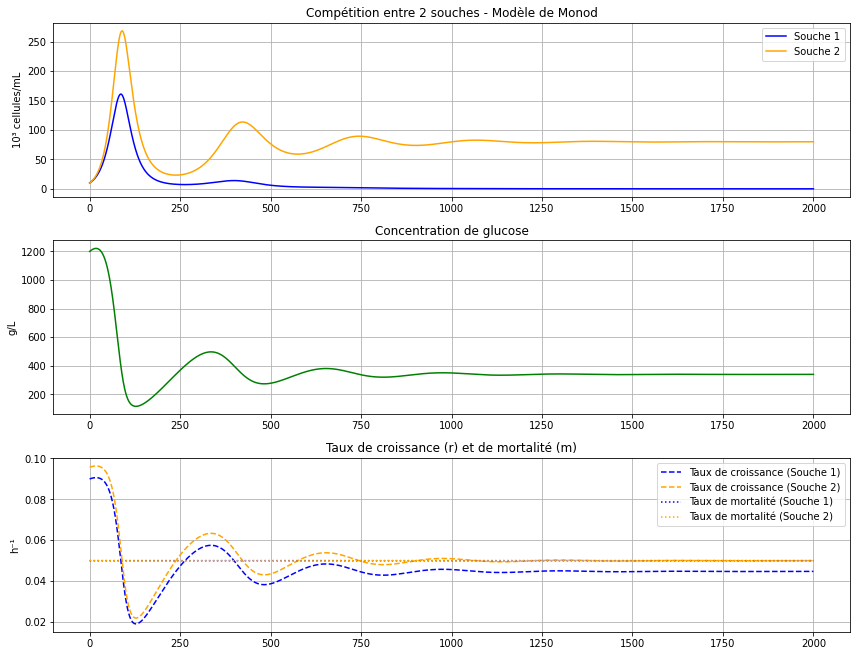

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# Paramètres pour la souche 1
# =============================================
rmax_1 = 0.15      # Taux de croissance maximal (souche 1)
m0_1 = 0.05      # Taux de mortalité de base (souche 1)
K_1 = 800        # Constante de demi-saturation (souche 1)

# =============================================
# Paramètres pour la souche 2
# =============================================
rmax_2 = 0.15      # Taux de croissance maximal (souche 2)
m0_2 = 0.05      # Taux de mortalité de base (souche 2)
K_2 = 680      # Constante de demi-saturation (souche 2) - affinité plus élevée pour le glucose

# =============================================
# Paramètres du glucose
# =============================================
initial_glucose = 1200   # Quantité initiale de glucose
glucose_inflow = 4      # Flux entrant de glucose (0 = système fermé)

# =============================================
# Conditions initiales
# =============================================
C0_1 = 10  # Concentration initiale de la souche 1
C0_2 = 10   # Concentration initiale de la souche 2

# =============================================
# Paramètres de la simulation
# =============================================
dt = 0.1         # Pas de temps
T = 2000         # Durée totale de la simulation
N_steps = int(T / dt)# Nombre de pas de temps

# =============================================
# Initialisation des tableaux
# =============================================
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)
mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)

# Conditions initiales
C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose
growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])
growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])
mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2

# =============================================
# Simulation
# =============================================
for i in range(1, N_steps):
    # Calcul des taux de croissance pour chaque souche (modèle de Monod)
    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    # Mortalité variable (augmente si le glucose est faible)
    #m_1 = m0_1 + 0.01 * (1 - glucose_level[i-1] / initial_glucose)
    #m_2 = m0_2 + 0.01 * (1 - glucose_level[i-1] / initial_glucose)

      # Mortalité constante
    m_1 = m0_1 
    m_2 = m0_2
    
    # Mise à jour des populations bactériennes
    C1[i] = C1[i-1] + dt * (r_1 - m_1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r_2 - m_2) * C2[i-1]

    # Consommation totale de glucose (somme des consommations des deux souches)
    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])
    glucose_level[i] = glucose_level[i-1] - dt * glucose_consumption + glucose_inflow * dt

    # Stockage des taux
    growth_rate_1[i] = r_1
    growth_rate_2[i] = r_2
    mortality_rate_1[i] = m_1
    mortality_rate_2[i] = m_2

# =============================================
# Temps pour l'axe des abscisses
# =============================================
time = np.linspace(0, T, N_steps)

# =============================================
# Tracé des courbes
# =============================================
plt.figure(figsize=(12, 12))

# Population des bactéries
plt.subplot(4, 1, 1)
plt.plot(time, C1, label='Souche 1', color='blue')
plt.plot(time, C2, label='Souche 2', color='orange')
plt.title('Compétition entre 2 souches - Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.legend()
plt.grid(True)

# Niveau de glucose
plt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)

# Taux de croissance et mortalité
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')
plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')
plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
plt.title('Taux de croissance (r) et de mortalité (m)')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)

# Taux de mortalité
#plt.subplot(4, 1, 4)
#plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
#plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
#plt.title('Taux de mortalité (m) au fil du temps')
#plt.xlabel('Temps')
#plt.ylabel('Taux de mortalité (m)')
#plt.legend()
#plt.grid(True)

plt.tight_layout()
plt.show()

Un taux de mortalité de m = 0.05 suffit à ce que la souche 1 domine la souche 2. La souche une plus resistante au manque de nutriment grignote plus les quantités de glucose à faible concentration jusqu'à trop faible concentration entrainant la souche 2 en dessous de son taux de mortalité de manière irréversible.

Les deux souches coexistent pour une meme affinité au glucose avec le meme taux de mortalité, mais si on garde le meme taux de mortalité de la souche 1 inférieur à celui de la souche 2, en augmentant un peu plus l'affinité de la souche 2 ou alors en plaçant le taux de mortalité jsute en dessous de la souche 2, les deux populations seront à l'équilibre.

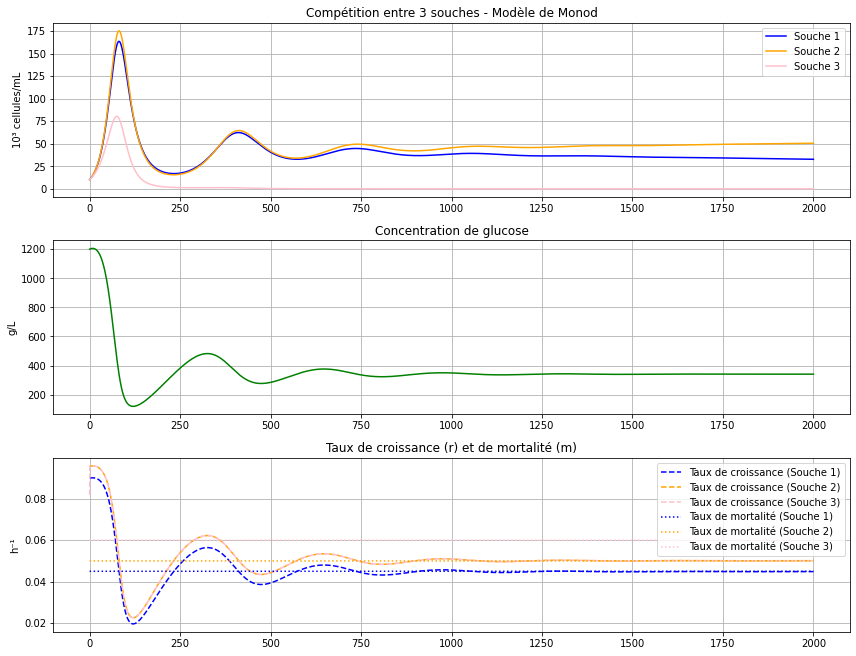

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# Paramètres pour la souche 1
# =============================================
rmax_1 = 0.15      # Taux de croissance maximal (souche 1)
m0_1 = 0.045      # Taux de mortalité de base (souche 1)
K_1 = 800        # Constante de demi-saturation (souche 1)

# =============================================
# Paramètres pour la souche 2
# =============================================
rmax_2 = 0.15      # Taux de croissance maximal (souche 2)
m0_2 = 0.05      # Taux de mortalité de base (souche 2)
K_2 = 680      # Constante de demi-saturation (souche 2) - affinité plus élevée pour le glucose

# =============================================
# Paramètres pour la souche 3
# =============================================
rmax_3 = 0.15      # Taux de croissance maximal (souche 1)
m0_3 = 0.06      # Taux de mortalité de base (souche 1)
K_3 = 1000        # Constante de demi-saturation (souche 1)


# =============================================
# Paramètres du glucose
# =============================================
initial_glucose = 1200   # Quantité initiale de glucose
glucose_inflow = 4      # Flux entrant de glucose (0 = système fermé)

# =============================================
# Conditions initiales
# =============================================
C0_1 = 10  # Concentration initiale de la souche 1
C0_2 = 10   # Concentration initiale de la souche 2
C0_3 = 10   # Concentration initiale de la souche 3

# =============================================
# Paramètres de la simulation
# =============================================
dt = 0.1         # Pas de temps
T = 2000         # Durée totale de la simulation
N_steps = int(T / dt)# Nombre de pas de temps

# =============================================
# Initialisation des tableaux
# =============================================
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
C3 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)
growth_rate_3 = np.zeros(N_steps)
mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)
mortality_rate_3 = np.zeros(N_steps)

# Conditions initiales
C1[0] = C0_1
C2[0] = C0_2
C3[0] = C0_3
glucose_level[0] = initial_glucose
growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])
growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])
growth_rate_3[0] = rmax_3 * glucose_level[0] / (K_3 + glucose_level[0])
mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2
mortality_rate_3[0] = m0_3

# =============================================
# Simulation
# =============================================
for i in range(1, N_steps):
    # Calcul des taux de croissance pour chaque souche (modèle de Monod)
    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])
    r_3 = rmax_3 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    # Mortalité variable (augmente si le glucose est faible)
    #m_1 = m0_1 + 0.01 * (1 - glucose_level[i-1] / initial_glucose)
    #m_2 = m0_2 + 0.01 * (1 - glucose_level[i-1] / initial_glucose)

      # Mortalité constante
    m_1 = m0_1 
    m_2 = m0_2
    m_3 = m0_3
    
    # Mise à jour des populations bactériennes
    C1[i] = C1[i-1] + dt * (r_1 - m_1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r_2 - m_2) * C2[i-1]
    C3[i] = C3[i-1] + dt * (r_3 - m_3) * C3[i-1]

    # Consommation totale de glucose (somme des consommations des deux souches)
    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1] + r_3 * C3[i-1])
    glucose_level[i] = glucose_level[i-1] - dt * glucose_consumption + glucose_inflow * dt

    # Stockage des taux
    growth_rate_1[i] = r_1
    growth_rate_2[i] = r_2
    growth_rate_3[i] = r_3
    mortality_rate_1[i] = m_1
    mortality_rate_2[i] = m_2
    mortality_rate_3[i] = m_3

# =============================================
# Temps pour l'axe des abscisses
# =============================================
time = np.linspace(0, T, N_steps)

# =============================================
# Tracé des courbes
# =============================================
plt.figure(figsize=(12, 12))

# Population des bactéries
plt.subplot(4, 1, 1)
plt.plot(time, C1, label='Souche 1', color='blue')
plt.plot(time, C2, label='Souche 2', color='orange')
plt.plot(time, C3, label='Souche 3', color='pink')
plt.title('Compétition entre 3 souches - Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.legend()
plt.grid(True)

# Niveau de glucose
plt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)

# Taux de croissance et mortalité
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')
plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')
plt.plot(time, growth_rate_3, label='Taux de croissance (Souche 3)', color='pink', linestyle='--')
plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
plt.plot(time, mortality_rate_3, label='Taux de mortalité (Souche 3)', color='pink', linestyle=':')
plt.title('Taux de croissance (r) et de mortalité (m)')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)

# Taux de mortalité
#plt.subplot(4, 1, 4)
#plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
#plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
#plt.title('Taux de mortalité (m) au fil du temps')
#plt.xlabel('Temps')
#plt.ylabel('Taux de mortalité (m)')
#plt.legend()
#plt.grid(True)

plt.tight_layout()
plt.show()

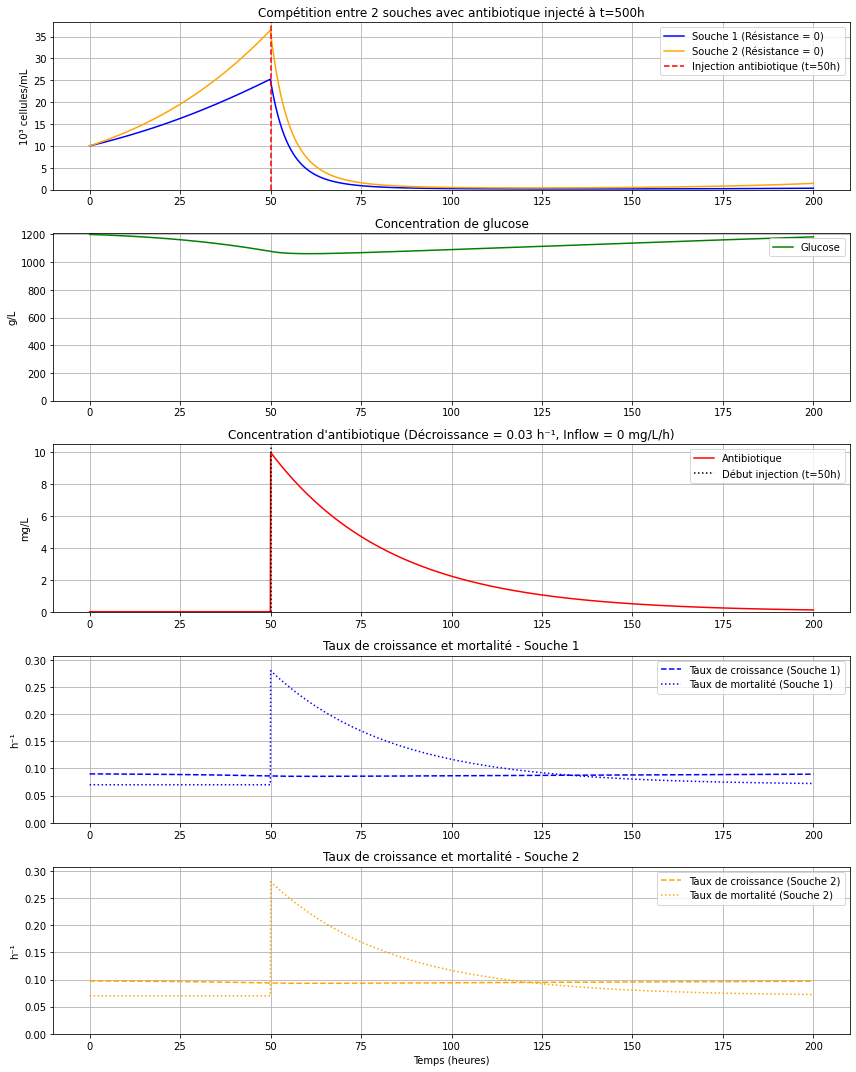

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# PARAMÈTRES POUR LES SOUCHES
# =============================================
# Souche 1
rmax_1 = 0.15      # Taux de croissance maximal (h⁻¹)
m0_1 = 0.07        # Taux de mortalité de base (h⁻¹)
K_1 = 800              # Constante de demi-saturation (g/L)
resistance_1 = 0  # Résistance à l'antibiotique (0 = aucune, 1 = totale)

# Souche 2
rmax_2 = 0.15      # Taux de croissance maximal (h⁻¹)
m0_2 = 0.07        # Taux de mortalité de base (h⁻¹)
K_2 = 650          # Constante de demi-saturation (g/L)
resistance_2 = 0 # Résistance à l'antibiotique

# =============================================
# PARAMÈTRES DU GLUCOSE
# =============================================
initial_glucose = 1200   # Concentration initiale de glucose (g/L)
glucose_inflow = 1      # Flux entrant de glucose (g/L/h)

# =============================================
# PARAMÈTRES DE L'ANTIBIOTIQUE
# =============================================
initial_antibiotic = 10   # Concentration initiale d'antibiotique (mg/L)
antibiotic_intensity = 3 # Intensité (0 = aucun effet, 1 = mortalité doublée)
antibiotic_decay = 0.03    # Taux de décroissance naturelle (h⁻¹)
antibiotic_inflow = 0      # Flux entrant d'antibiotique (mg/L/h)
antibiotic_start_time = 50  # Temps (en heures) avant l'injection

# =============================================
# CONDITIONS INITIALES
# =============================================
C0_1 = 10  # Concentration initiale de la souche 1 (10³ cellules/mL)
C0_2 = 10  # Concentration initiale de la souche 2 (10³ cellules/mL)

# =============================================
# PARAMÈTRES DE LA SIMULATION
# =============================================
dt = 0.1          # Pas de temps (h)
T = 200          # Durée totale (h)
N_steps = int(T / dt)

# =============================================
# INITIALISATION DES TABLEAUX
# =============================================
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
antibiotic_level = np.zeros(N_steps)
growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)
mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)

# Conditions initiales
C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose
antibiotic_level[0] = 0
growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])
growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])
mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2

# =============================================
# SIMULATION
# =============================================
for i in range(1, N_steps):
    current_time = i * dt

    # Calcul des taux de croissance
    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    # Mise à jour de l'antibiotique (CORRIGÉ)
    if current_time < antibiotic_start_time:
        antibiotic_level[i] = 0
    else:
        if antibiotic_level[i-1] == 0:  # Premier pas après l'injection
            antibiotic_level[i] = initial_antibiotic
        else:
            antibiotic_level[i] = antibiotic_level[i-1] * (1 - antibiotic_decay * dt) + antibiotic_inflow * dt

    # Effet de l'antibiotique sur la mortalité
    if antibiotic_level[i] > 0:
        antibiotic_effect_1 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_1)
        antibiotic_effect_2 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_2)
    else:
        antibiotic_effect_1 = 0
        antibiotic_effect_2 = 0

    m_1 = m0_1 * (1 + antibiotic_effect_1)
    m_2 = m0_2 * (1 + antibiotic_effect_2)

    # Mise à jour des populations
    C1[i] = C1[i-1] + dt * (r_1 - m_1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r_2 - m_2) * C2[i-1]

    # Consommation de glucose
    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])
    glucose_level[i] = glucose_level[i-1] - dt * glucose_consumption + glucose_inflow * dt

    # Stockage des taux
    growth_rate_1[i] = r_1
    growth_rate_2[i] = r_2
    mortality_rate_1[i] = m_1
    mortality_rate_2[i] = m_2

# =============================================
# TEMPS POUR L'AXE DES ABCISSES
# =============================================
time = np.linspace(0, T, N_steps)

# =============================================
# CALCUL DES ÉCHELLES COMMUNES POUR LES TAUX
# =============================================
# Trouver le maximum global pour les taux de croissance et mortalité
max_growth = max(np.max(growth_rate_1), np.max(growth_rate_2))
max_mortality = max(np.max(mortality_rate_1), np.max(mortality_rate_2))
y_max_rates = max(max_growth, max_mortality) * 1.1  # +10% de marge

# =============================================
# TRACÉ DES COURBES
# =============================================
plt.figure(figsize=(12, 15))

# 1. Populations bactériennes
plt.subplot(5, 1, 1)
plt.plot(time, C1, label=f'Souche 1 (Résistance = {resistance_1})', color='blue')
plt.plot(time, C2, label=f'Souche 2 (Résistance = {resistance_2})', color='orange')
plt.axvline(x=antibiotic_start_time, color='red', linestyle='--', label=f'Injection antibiotique (t={antibiotic_start_time}h)')
plt.title('Compétition entre 2 souches avec antibiotique injecté à t=500h')
plt.ylabel('10³ cellules/mL')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 2. Concentration de glucose
plt.subplot(5, 1, 2)
plt.plot(time, glucose_level, label='Glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 3. Concentration d'antibiotique
plt.subplot(5, 1, 3)
plt.plot(time, antibiotic_level, label='Antibiotique', color='red')
plt.axvline(x=antibiotic_start_time, color='black', linestyle=':', label=f'Début injection (t={antibiotic_start_time}h)')
plt.title(f'Concentration d\'antibiotique (Décroissance = {antibiotic_decay} h⁻¹, Inflow = {antibiotic_inflow} mg/L/h)')
plt.ylabel('mg/L')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 4. Taux de croissance et mortalité (Souche 1)
plt.subplot(5, 1, 4)
plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')
plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
plt.title('Taux de croissance et mortalité - Souche 1')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0, top=y_max_rates)  # Échelle commune

# 5. Taux de croissance et mortalité (Souche 2)
plt.subplot(5, 1, 5)
plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')
plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
plt.title('Taux de croissance et mortalité - Souche 2')
plt.xlabel('Temps (heures)')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0, top=y_max_rates)  # Même échelle que le graphique 4

plt.tight_layout()
plt.show()

Les souches après injection de l'antibiotique ont une très forte hausse du taux de mortaltié causant une chute de population des deux souches à 0 et ce malgré une légère augmentation de la concentration de glucose.

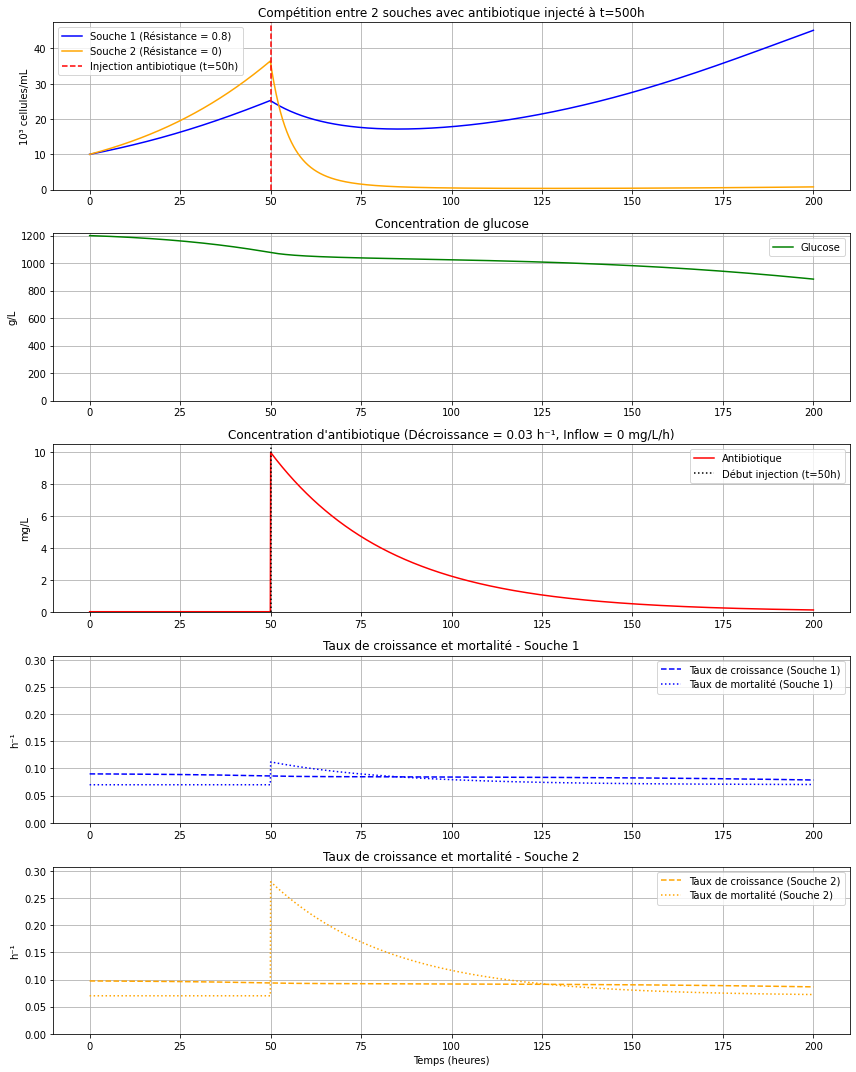

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# PARAMÈTRES POUR LES SOUCHES
# =============================================
# Souche 1
rmax_1 = 0.15      # Taux de croissance maximal (h⁻¹)
m0_1 = 0.07        # Taux de mortalité de base (h⁻¹)
K_1 = 800              # Constante de demi-saturation (g/L)
resistance_1 = 0.8  # Résistance à l'antibiotique (0 = aucune, 1 = totale)

# Souche 2
rmax_2 = 0.15      # Taux de croissance maximal (h⁻¹)
m0_2 = 0.07        # Taux de mortalité de base (h⁻¹)
K_2 = 650          # Constante de demi-saturation (g/L)
resistance_2 = 0 # Résistance à l'antibiotique

# =============================================
# PARAMÈTRES DU GLUCOSE
# =============================================
initial_glucose = 1200   # Concentration initiale de glucose (g/L)
glucose_inflow = 1      # Flux entrant de glucose (g/L/h)

# =============================================
# PARAMÈTRES DE L'ANTIBIOTIQUE
# =============================================
initial_antibiotic = 10   # Concentration initiale d'antibiotique (mg/L)
antibiotic_intensity = 3 # Intensité (0 = aucun effet, 1 = mortalité doublée)
antibiotic_decay = 0.03    # Taux de décroissance naturelle (h⁻¹)
antibiotic_inflow = 0      # Flux entrant d'antibiotique (mg/L/h)
antibiotic_start_time = 50  # Temps (en heures) avant l'injection

# =============================================
# CONDITIONS INITIALES
# =============================================
C0_1 = 10  # Concentration initiale de la souche 1 (10³ cellules/mL)
C0_2 = 10  # Concentration initiale de la souche 2 (10³ cellules/mL)

# =============================================
# PARAMÈTRES DE LA SIMULATION
# =============================================
dt = 0.1          # Pas de temps (h)
T = 200          # Durée totale (h)
N_steps = int(T / dt)

# =============================================
# INITIALISATION DES TABLEAUX
# =============================================
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
antibiotic_level = np.zeros(N_steps)
growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)
mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)

# Conditions initiales
C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose
antibiotic_level[0] = 0
growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])
growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])
mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2

# =============================================
# SIMULATION
# =============================================
for i in range(1, N_steps):
    current_time = i * dt

    # Calcul des taux de croissance
    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    # Mise à jour de l'antibiotique (CORRIGÉ)
    if current_time < antibiotic_start_time:
        antibiotic_level[i] = 0
    else:
        if antibiotic_level[i-1] == 0:  # Premier pas après l'injection
            antibiotic_level[i] = initial_antibiotic
        else:
            antibiotic_level[i] = antibiotic_level[i-1] * (1 - antibiotic_decay * dt) + antibiotic_inflow * dt

    # Effet de l'antibiotique sur la mortalité
    if antibiotic_level[i] > 0:
        antibiotic_effect_1 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_1)
        antibiotic_effect_2 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_2)
    else:
        antibiotic_effect_1 = 0
        antibiotic_effect_2 = 0

    m_1 = m0_1 * (1 + antibiotic_effect_1)
    m_2 = m0_2 * (1 + antibiotic_effect_2)

    # Mise à jour des populations
    C1[i] = C1[i-1] + dt * (r_1 - m_1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r_2 - m_2) * C2[i-1]

    # Consommation de glucose
    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])
    glucose_level[i] = glucose_level[i-1] - dt * glucose_consumption + glucose_inflow * dt

    # Stockage des taux
    growth_rate_1[i] = r_1
    growth_rate_2[i] = r_2
    mortality_rate_1[i] = m_1
    mortality_rate_2[i] = m_2

# =============================================
# TEMPS POUR L'AXE DES ABCISSES
# =============================================
time = np.linspace(0, T, N_steps)

# =============================================
# CALCUL DES ÉCHELLES COMMUNES POUR LES TAUX
# =============================================
# Trouver le maximum global pour les taux de croissance et mortalité
max_growth = max(np.max(growth_rate_1), np.max(growth_rate_2))
max_mortality = max(np.max(mortality_rate_1), np.max(mortality_rate_2))
y_max_rates = max(max_growth, max_mortality) * 1.1  # +10% de marge

# =============================================
# TRACÉ DES COURBES
# =============================================
plt.figure(figsize=(12, 15))

# 1. Populations bactériennes
plt.subplot(5, 1, 1)
plt.plot(time, C1, label=f'Souche 1 (Résistance = {resistance_1})', color='blue')
plt.plot(time, C2, label=f'Souche 2 (Résistance = {resistance_2})', color='orange')
plt.axvline(x=antibiotic_start_time, color='red', linestyle='--', label=f'Injection antibiotique (t={antibiotic_start_time}h)')
plt.title('Compétition entre 2 souches avec antibiotique injecté à t=500h')
plt.ylabel('10³ cellules/mL')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 2. Concentration de glucose
plt.subplot(5, 1, 2)
plt.plot(time, glucose_level, label='Glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 3. Concentration d'antibiotique
plt.subplot(5, 1, 3)
plt.plot(time, antibiotic_level, label='Antibiotique', color='red')
plt.axvline(x=antibiotic_start_time, color='black', linestyle=':', label=f'Début injection (t={antibiotic_start_time}h)')
plt.title(f'Concentration d\'antibiotique (Décroissance = {antibiotic_decay} h⁻¹, Inflow = {antibiotic_inflow} mg/L/h)')
plt.ylabel('mg/L')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 4. Taux de croissance et mortalité (Souche 1)
plt.subplot(5, 1, 4)
plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')
plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
plt.title('Taux de croissance et mortalité - Souche 1')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0, top=y_max_rates)  # Échelle commune

# 5. Taux de croissance et mortalité (Souche 2)
plt.subplot(5, 1, 5)
plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')
plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
plt.title('Taux de croissance et mortalité - Souche 2')
plt.xlabel('Temps (heures)')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0, top=y_max_rates)  # Même échelle que le graphique 4

plt.tight_layout()
plt.show()

A présent grace à la résistance à l'antibiotique, la souche 1 ne subit qu'une très légère hausse du taux de mortalité au dessus du taux de croissance mais très vite repassant en dessous de cette dernière et menant à la survie et la croissance de la souche 1, à l'inverse de la souche 2.

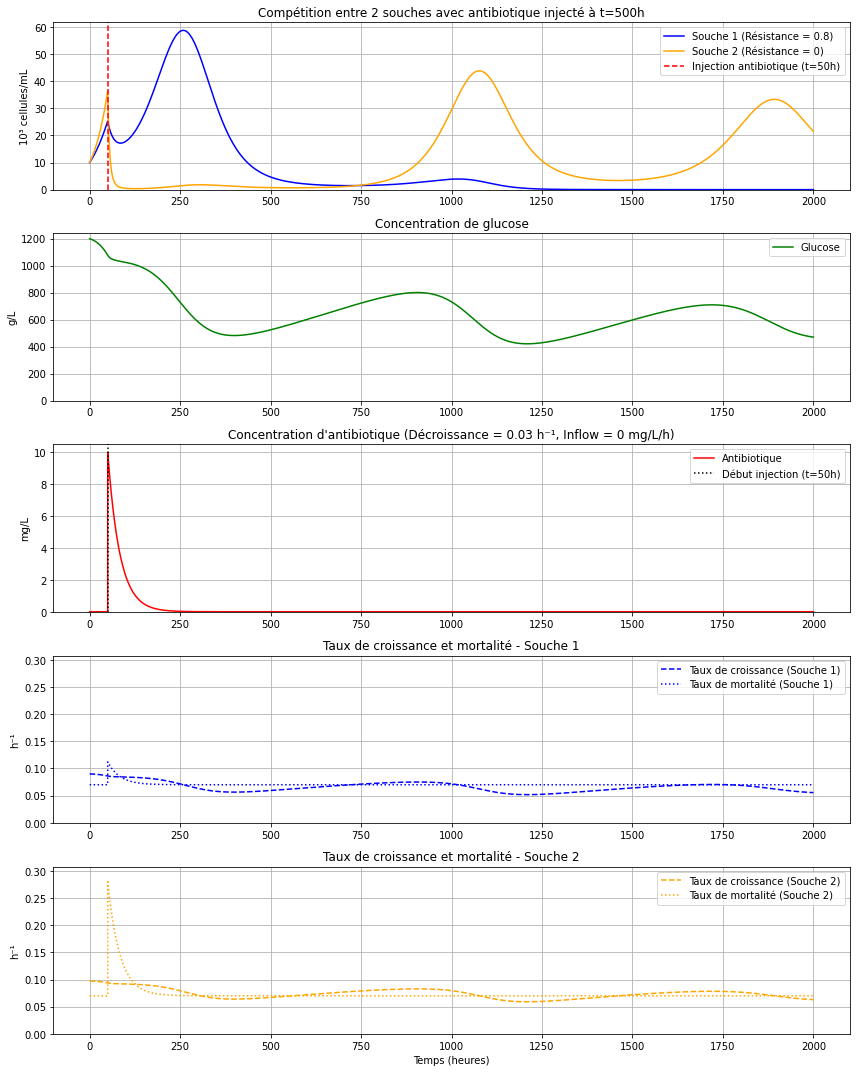

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# PARAMÈTRES POUR LES SOUCHES
# =============================================
# Souche 1
rmax_1 = 0.15      # Taux de croissance maximal (h⁻¹)
m0_1 = 0.07        # Taux de mortalité de base (h⁻¹)
K_1 = 800              # Constante de demi-saturation (g/L)
resistance_1 = 0.8  # Résistance à l'antibiotique (0 = aucune, 1 = totale)

# Souche 2
rmax_2 = 0.15      # Taux de croissance maximal (h⁻¹)
m0_2 = 0.07        # Taux de mortalité de base (h⁻¹)
K_2 = 650          # Constante de demi-saturation (g/L)
resistance_2 = 0 # Résistance à l'antibiotique

# =============================================
# PARAMÈTRES DU GLUCOSE
# =============================================
initial_glucose = 1200   # Concentration initiale de glucose (g/L)
glucose_inflow = 1      # Flux entrant de glucose (g/L/h)

# =============================================
# PARAMÈTRES DE L'ANTIBIOTIQUE
# =============================================
initial_antibiotic = 10   # Concentration initiale d'antibiotique (mg/L)
antibiotic_intensity = 3 # Intensité (0 = aucun effet, 1 = mortalité doublée)
antibiotic_decay = 0.03    # Taux de décroissance naturelle (h⁻¹)
antibiotic_inflow = 0      # Flux entrant d'antibiotique (mg/L/h)
antibiotic_start_time = 50  # Temps (en heures) avant l'injection

# =============================================
# CONDITIONS INITIALES
# =============================================
C0_1 = 10  # Concentration initiale de la souche 1 (10³ cellules/mL)
C0_2 = 10  # Concentration initiale de la souche 2 (10³ cellules/mL)

# =============================================
# PARAMÈTRES DE LA SIMULATION
# =============================================
dt = 0.1          # Pas de temps (h)
T = 2000          # Durée totale (h)
N_steps = int(T / dt)

# =============================================
# INITIALISATION DES TABLEAUX
# =============================================
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
antibiotic_level = np.zeros(N_steps)
growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)
mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)

# Conditions initiales
C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose
antibiotic_level[0] = 0
growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])
growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])
mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2

# =============================================
# SIMULATION
# =============================================
for i in range(1, N_steps):
    current_time = i * dt

    # Calcul des taux de croissance
    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    # Mise à jour de l'antibiotique (CORRIGÉ)
    if current_time < antibiotic_start_time:
        antibiotic_level[i] = 0
    else:
        if antibiotic_level[i-1] == 0:  # Premier pas après l'injection
            antibiotic_level[i] = initial_antibiotic
        else:
            antibiotic_level[i] = antibiotic_level[i-1] * (1 - antibiotic_decay * dt) + antibiotic_inflow * dt

    # Effet de l'antibiotique sur la mortalité
    if antibiotic_level[i] > 0:
        antibiotic_effect_1 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_1)
        antibiotic_effect_2 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_2)
    else:
        antibiotic_effect_1 = 0
        antibiotic_effect_2 = 0

    m_1 = m0_1 * (1 + antibiotic_effect_1)
    m_2 = m0_2 * (1 + antibiotic_effect_2)

    # Mise à jour des populations
    C1[i] = C1[i-1] + dt * (r_1 - m_1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r_2 - m_2) * C2[i-1]

    # Consommation de glucose
    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])
    glucose_level[i] = glucose_level[i-1] - dt * glucose_consumption + glucose_inflow * dt

    # Stockage des taux
    growth_rate_1[i] = r_1
    growth_rate_2[i] = r_2
    mortality_rate_1[i] = m_1
    mortality_rate_2[i] = m_2

# =============================================
# TEMPS POUR L'AXE DES ABCISSES
# =============================================
time = np.linspace(0, T, N_steps)

# =============================================
# CALCUL DES ÉCHELLES COMMUNES POUR LES TAUX
# =============================================
# Trouver le maximum global pour les taux de croissance et mortalité
max_growth = max(np.max(growth_rate_1), np.max(growth_rate_2))
max_mortality = max(np.max(mortality_rate_1), np.max(mortality_rate_2))
y_max_rates = max(max_growth, max_mortality) * 1.1  # +10% de marge

# =============================================
# TRACÉ DES COURBES
# =============================================
plt.figure(figsize=(12, 15))

# 1. Populations bactériennes
plt.subplot(5, 1, 1)
plt.plot(time, C1, label=f'Souche 1 (Résistance = {resistance_1})', color='blue')
plt.plot(time, C2, label=f'Souche 2 (Résistance = {resistance_2})', color='orange')
plt.axvline(x=antibiotic_start_time, color='red', linestyle='--', label=f'Injection antibiotique (t={antibiotic_start_time}h)')
plt.title('Compétition entre 2 souches avec antibiotique injecté à t=500h')
plt.ylabel('10³ cellules/mL')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 2. Concentration de glucose
plt.subplot(5, 1, 2)
plt.plot(time, glucose_level, label='Glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 3. Concentration d'antibiotique
plt.subplot(5, 1, 3)
plt.plot(time, antibiotic_level, label='Antibiotique', color='red')
plt.axvline(x=antibiotic_start_time, color='black', linestyle=':', label=f'Début injection (t={antibiotic_start_time}h)')
plt.title(f'Concentration d\'antibiotique (Décroissance = {antibiotic_decay} h⁻¹, Inflow = {antibiotic_inflow} mg/L/h)')
plt.ylabel('mg/L')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 4. Taux de croissance et mortalité (Souche 1)
plt.subplot(5, 1, 4)
plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')
plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
plt.title('Taux de croissance et mortalité - Souche 1')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0, top=y_max_rates)  # Échelle commune

# 5. Taux de croissance et mortalité (Souche 2)
plt.subplot(5, 1, 5)
plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')
plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
plt.title('Taux de croissance et mortalité - Souche 2')
plt.xlabel('Temps (heures)')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0, top=y_max_rates)  # Même échelle que le graphique 4

plt.tight_layout()
plt.show()

Les 750 premières heures la souche 1 croit fortement et la souche 2 chute fortement quasiment à 0. Mais passée la 750ième heure, les quelques souches résistantes de la souche 2 croit de nouveau après la baisse de concentration d'antibiotiques.

Ici sur une période 10 fois plus longue, la souche 2 n'étant pas totalement à 0, lorsque la population de la souche 1 baisse  à cause de la concentration de glucose faible, les quelques cellules survivantes prennent l'avantage par leur affinité et réussissent à croitre légèrement en oscillant jusqu'à totale adaptation au milieu grace à la resistance des mutants et puis prolifération, la souche 2 obtient dans le long terme et une meilleure affinité au glucose et une resistance à l'antibiotique gagnée par mutation et séléction, reprenant ensuite le dessus de la souche 1 comme dans des conditions de bases. D'où l'importance de la pollution résiduelle d'antibiotiques sélectionnant les souches résistantes.